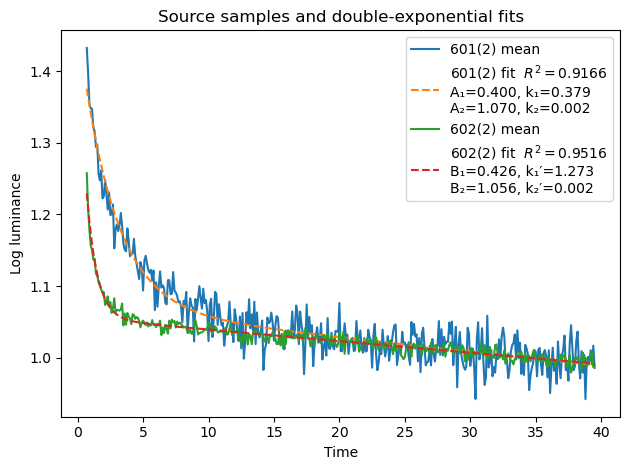

A1: 0.400, A2: 1.070, B1: 0.426, B2: 1.056 r2_601 0.917
k1: 0.379, k2: 0.002, k1b: 1.273, k2b: 0.002 r2_602 0.952


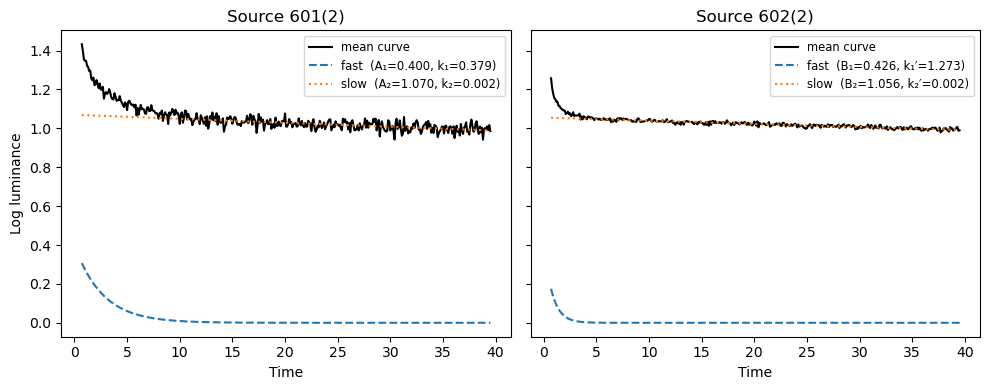

In [9]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -------------------- Helper utilities --------------------
def load_data(path="output/processed_new_data_log.pkl"):
    """Load the pickled dictionary that contains all sample dataframes."""
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Pickle file not found at '{path}'. Please make sure the path is correct."
        )
    with open(path, "rb") as f:
        return pickle.load(f)


def mean_curve(df, key):
    """
    Return time vector and the mean of all slice columns for a given dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe corresponding to one sample.
    key : str
        The sample key, e.g. '601(2)' or '511'.  The part before a '(' (if any)
        is used to match slice‑column names, e.g. 'Sample_601'.
    """
    prefix = f"Sample_{key.split('(')[0]}"
    slice_cols = [c for c in df.columns if c.startswith(prefix)]
    t = df["Time"].values.astype(float)
    y = df[slice_cols].mean(axis=1).values.astype(float)
    return t, y


def double_exp(t, A1, k1, A2, k2):
    """Two‑term exponential decay."""
    return A1 * np.exp(-k1 * t) + A2 * np.exp(-k2 * t)


def r2_score(y_true, y_pred):
    sst = np.sum((y_true - np.mean(y_true)) ** 2)
    sse = np.sum((y_true - y_pred) ** 2)
    return 1.0 - sse / sst


# -------------------- STEP 1: fit the two “source” samples --------------------
data_dict = load_data()

# Fit sample 601(2)
t_601, y_601 = mean_curve(data_dict["601(2)"], "601(2)")
p0_601 = [1.0, 0.05, 0.5, 0.005]  # rough starting guesses
A1, k1, A2, k2 = curve_fit(double_exp, t_601, y_601, p0=p0_601, maxfev=10000)[0]
fit_601 = double_exp(t_601, A1, k1, A2, k2)
r2_601 = r2_score(y_601, fit_601)

# Fit sample 602(2)
t_602, y_602 = mean_curve(data_dict["602(2)"], "602(2)")
p0_602 = [A1, k1, A2, k2]  # use previous fit as a reasonable initial guess
B1, k1b, B2, k2b = curve_fit(double_exp, t_602, y_602, p0=p0_602, maxfev=10000)[0]
fit_602 = double_exp(t_602, B1, k1b, B2, k2b)
r2_602 = r2_score(y_602, fit_602)

# Plot the two means and their double‑exponential fits
plt.figure()
plt.plot(t_601, y_601, label="601(2) mean")
plt.plot(
    t_601,
    fit_601,
    "--",
    label=(
        f"601(2) fit  $R^2={r2_601:.4f}$\n"
        f"A₁={A1:.3f}, k₁={k1:.3f}\nA₂={A2:.3f}, k₂={k2:.3f}"
    ),
)
plt.plot(t_602, y_602, label="602(2) mean")
plt.plot(
    t_602,
    fit_602,
    "--",
    label=(
        f"602(2) fit  $R^2={r2_602:.4f}$\n"
        f"B₁={B1:.3f}, k₁′={k1b:.3f}\nB₂={B2:.3f}, k₂′={k2b:.3f}"
    ),
)
plt.xlabel("Time")
plt.ylabel("Log luminance")
plt.title("Source samples and double‑exponential fits")
plt.legend()
plt.tight_layout()
plt.show()


# print A1, A2, B1, B2 AND k1, k2, k1b, k2b
print(f"A1: {A1:.3f}, A2: {A2:.3f}, B1: {B1:.3f}, B2: {B2:.3f}",'r2_601', f"{r2_601:.3f}")
print(f"k1: {k1:.3f}, k2: {k2:.3f}, k1b: {k1b:.3f}, k2b: {k2b:.3f}", 'r2_602', f"{r2_602:.3f}")



# ------------------------------------------------------------
#  Figure: 601(2) vs 602(2) – mean, fast term, slow term
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# ---------- 601(2) ----------
fast_601 = A1 * np.exp(-k1 * t_601)
slow_601 = A2 * np.exp(-k2 * t_601)

ax[0].plot(t_601, y_601,  color="k", label="mean curve")
ax[0].plot(t_601, fast_601, "--", label=f"fast  (A₁={A1:.3f}, k₁={k1:.3f})")
ax[0].plot(t_601, slow_601, ":",  label=f"slow  (A₂={A2:.3f}, k₂={k2:.3f})")
ax[0].set_title("Source 601(2)")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Log luminance")
ax[0].legend(fontsize="small")

# ---------- 602(2) ----------
fast_602 = B1 * np.exp(-k1b * t_602)
slow_602 = B2 * np.exp(-k2b * t_602)

ax[1].plot(t_602, y_602,  color="k", label="mean curve")
ax[1].plot(t_602, fast_602, "--", label=f"fast  (B₁={B1:.3f}, k₁′={k1b:.3f})")
ax[1].plot(t_602, slow_602, ":",  label=f"slow  (B₂={B2:.3f}, k₂′={k2b:.3f})")
ax[1].set_title("Source 602(2)")
ax[1].set_xlabel("Time")
ax[1].legend(fontsize="small")

plt.tight_layout()
plt.show()


Source 601(2): A1=0.400, k1=0.379, A2=1.070, k2=0.002
Source 602(2): B1=0.426, k1b=1.273, B2=1.056, k2b=0.002

=== Mixing fractions (a+b=1, non‑negative) ===
        Mix601 (a)  Mix602 (b)  Slow C′      R²
Sample                                         
511         0.2927      0.7073   1.0887  0.9265
512         0.4953      0.5047   1.0845  0.9508
513         0.4966      0.5034   1.0796  0.9637
514         0.4654      0.5346   1.0768  0.9599
515         0.1882      0.8118   1.0771  0.9564
516         0.6988      0.3012   1.0858  0.9685
517         0.3612      0.6388   1.0733  0.9797
518         0.9850      0.0150   1.0817  0.9537
522(2)      0.0421      0.9579   1.0633  0.9626
523(2)      0.1171      0.8829   1.0853  0.8660
524(2)      0.1046      0.8954   1.0860  0.8467
526(2)      0.0433      0.9567   1.0786  0.8780
527(2)      0.0166      0.9834   1.0760  0.8687
529(2)      0.0000      1.0000   1.0699  0.8868
530(2)      0.0099      0.9901   1.0649  0.9125
535         0.3465      0.

,Mix601 (a),Mix602 (b),Slow C′,R²
Sample,,,,
511,0.2927,0.7073,1.0887,0.9265
512,0.4953,0.5047,1.0845,0.9508
513,0.4966,0.5034,1.0796,0.9637
514,0.4654,0.5346,1.0768,0.9599
515,0.1882,0.8118,1.0771,0.9564
516,0.6988,0.3012,1.0858,0.9685
517,0.3612,0.6388,1.0733,0.9797
518,0.9850,0.0150,1.0817,0.9537
522(2),0.0421,0.9579,1.0633,0.9626


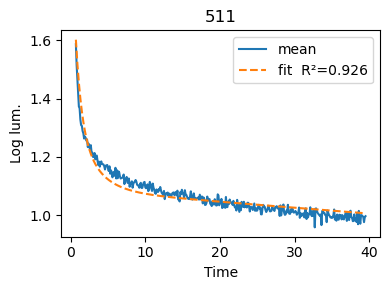

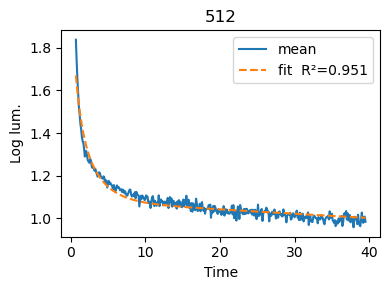

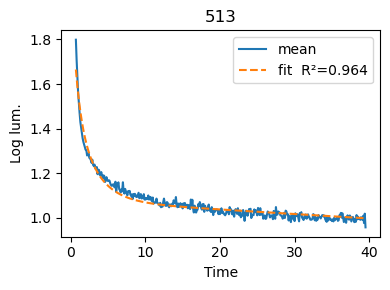

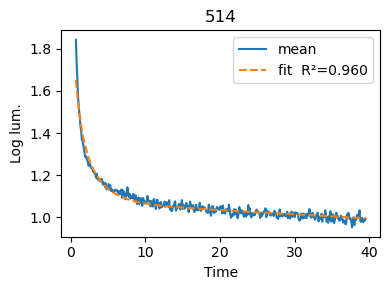

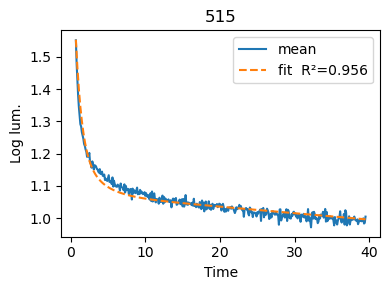

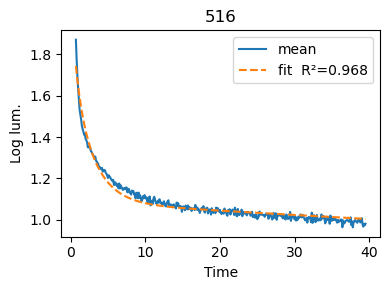

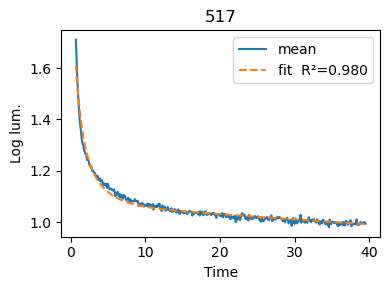

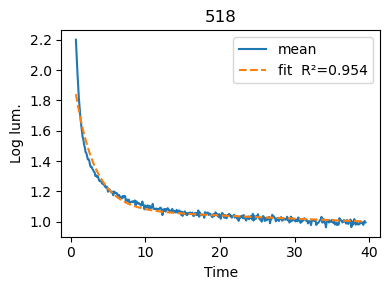

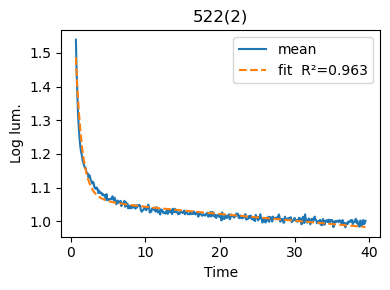

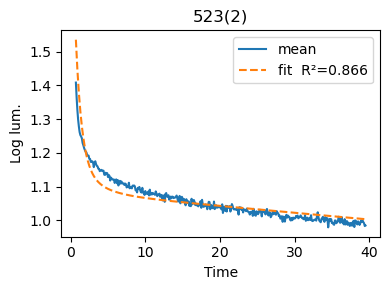

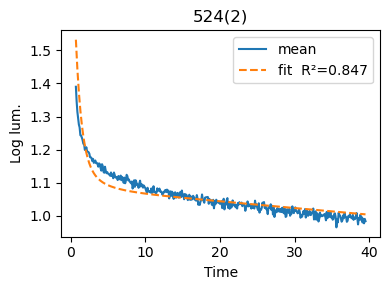

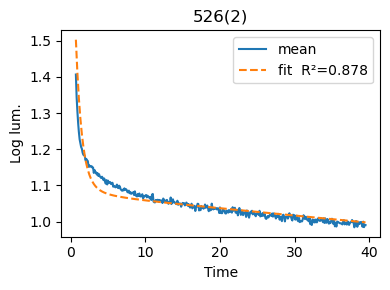

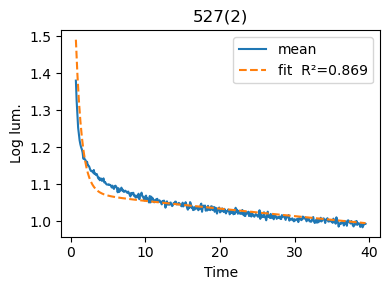

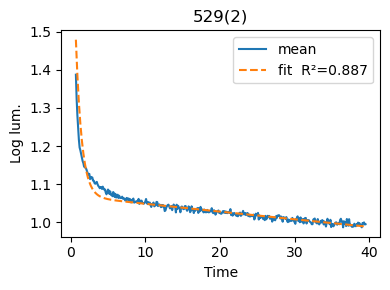

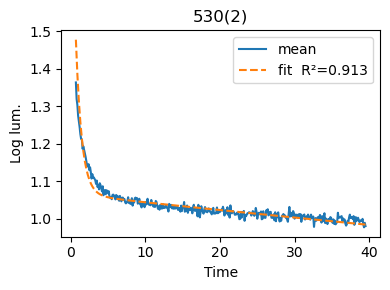

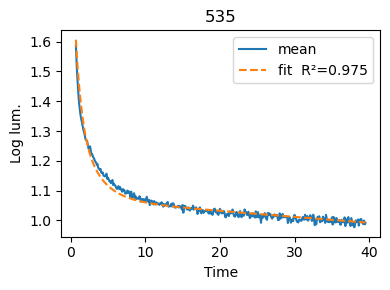

In [7]:
# ------------------------------------------------------------
# 0. Imports
# ------------------------------------------------------------
import os, pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import curve_fit, minimize
from IPython.display import display  # comment out if not using Jupyter

# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------
def load_data(path="output/processed_new_data_log.pkl"):
    if not os.path.exists(path):
        raise FileNotFoundError(f"pickle not found: {path}")
    with open(path, "rb") as f:
        return pickle.load(f)

def mean_curve(df, key):
    """Return time vector and mean of slice columns for one sample."""
    prefix = f"Sample_{key.split('(')[0]}"
    cols   = [c for c in df.columns if c.startswith(prefix)]
    t      = df["Time"].to_numpy(dtype=float)
    y      = df[cols].mean(axis=1).to_numpy(dtype=float)
    return t, y

def double_exp(t, A1, k1, A2, k2):
    return A1*np.exp(-k1*t) + A2*np.exp(-k2*t)

def r2(y, yhat):
    sst = np.sum((y - y.mean())**2)
    sse = np.sum((y - yhat)**2)
    return 1 - sse/sst

# ------------------------------------------------------------
# 2. Fit the two source samples 601(2) & 602(2)
# ------------------------------------------------------------
data = load_data()

t601, y601 = mean_curve(data["601(2)"], "601(2)")
p0   = (1.0, 0.05, 0.7, 0.005)
A1, k1, A2, k2 = curve_fit(double_exp, t601, y601, p0=p0, maxfev=8000)[0]

t602, y602 = mean_curve(data["602(2)"], "602(2)")
p0b  = (A1, k1, A2, k2)
B1, k1b, B2, k2b = curve_fit(double_exp, t602, y602, p0=p0b, maxfev=8000)[0]

print(f"Source 601(2): A1={A1:.3f}, k1={k1:.3f}, A2={A2:.3f}, k2={k2:.3f}")
print(f"Source 602(2): B1={B1:.3f}, k1b={k1b:.3f}, B2={B2:.3f}, k2b={k2b:.3f}")

# ------------------------------------------------------------
# 3. Basis functions for mixture model
#     f1 = exp(-k1 t)  (fast‑601)
#     f2 = exp(-k1b t) (fast‑602)
#     s  = exp(-k2 t)  (common slow)
# ------------------------------------------------------------
def basis_matrix3(t):
    return np.column_stack([np.exp(-k1*t), np.exp(-k1b*t), np.exp(-k2*t)])

# ------------------------------------------------------------
# 4. Constrained fit:  minimise ||y - (a*f1 + b*f2 + c*s)||²
#    subject to a>=0, b>=0, c>=0,  a+b=1   (so a,b are mixing ratios)
# ------------------------------------------------------------
def fit_constrained(t, y):
    X = basis_matrix3(t)
    f1, f2, s = X.T                      # three vectors

    def loss(w):
        a, b, c = w
        yhat = a*f1 + b*f2 + c*s
        return np.sum((y - yhat)**2)

    cons = ({'type':'eq', 'fun': lambda w: w[0] + w[1] - 1},)
    bnds = [(0, None), (0, None), (0, None)]
    res  = minimize(loss, x0=(0.5, 0.5, 1.0), bounds=bnds, constraints=cons)
    return res.x                 # a, b, c (a+b=1)

# ------------------------------------------------------------
# 5. Loop over all samples, excluding the two sources
# ------------------------------------------------------------
rows = []
for key, df in data.items():
    if key in ("601(2)", "602(2)"):
        continue                        # skip sources

    t, y   = mean_curve(df, key)
    a, b, c = fit_constrained(t, y)
    yfit    = a*np.exp(-k1*t) + b*np.exp(-k1b*t) + c*np.exp(-k2*t)
    r2full  = r2(y, yfit)

    rows.append([key, a, b, c, r2full])

    # ---- optional plot for each sample ----
    plt.figure(figsize=(4,3))
    plt.plot(t, y,  label="mean")
    plt.plot(t, yfit, "--", label=f"fit  R²={r2full:.3f}")
    plt.title(key)
    plt.xlabel("Time"); plt.ylabel("Log lum.")
    plt.legend()
    plt.tight_layout()
    # plt.show()        # uncomment to see each plot

# ------------------------------------------------------------
# 6. Result table
# ------------------------------------------------------------
df_out = pd.DataFrame(
    rows, columns=["Sample", "Mix601 (a)", "Mix602 (b)", "Slow C′", "R²"]
).set_index("Sample").sort_index()

print("\n=== Mixing fractions (a+b=1, non‑negative) ===")
print(df_out.round(4).to_string())

# save to CSV if desired
df_out.to_csv("mixing_fractions.csv")
print("\nSaved table to mixing_fractions.csv")

# display in Jupyter
try:
    display(df_out.round(4))
except NameError:
    pass


In [1]:
import os, pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# -------------------- Load data --------------------
pickle_path = 'output/processed_new_data_log.pkl'
if not os.path.exists(pickle_path):
    raise FileNotFoundError("Pickle file not found at 'output/processed_new_data_log.pkl'.")

with open(pickle_path, 'rb') as f:
    data_dict = pickle.load(f)

print(data_dict.keys())  # Check available keys in the dictionary
data_dict

dict_keys(['511', '512', '513', '514', '515', '516', '517', '518', '522(2)', '523(2)', '524(2)', '526(2)', '527(2)', '529(2)', '530(2)', '535', '601(2)', '602(2)'])


{'511': 0    Time_index  Time  Sample_511(1)  Sample_511(10)  Sample_511(11)  \
 0             7   0.7       1.713178        1.581826        1.567982   
 1             8   0.8       1.616899        1.510238        1.522450   
 2             9   0.9       1.529434        1.474117        1.427298   
 3            10   1.0       1.482235        1.438011        1.413573   
 4            11   1.1       1.409124        1.396173        1.350927   
 ..          ...   ...            ...             ...             ...   
 384         391  39.1       0.990578        0.986794        1.044974   
 385         392  39.2       0.990578        1.010812        0.997325   
 386         393  39.3       1.013110        0.993007        0.929321   
 387         394  39.4       1.113854        0.938659        1.022143   
 388         395  39.5       1.013110        0.980432        0.997325   
 
 0    Sample_511(12)  Sample_511(13)  Sample_511(14)  Sample_511(15)  \
 0          1.559812        1.599463       

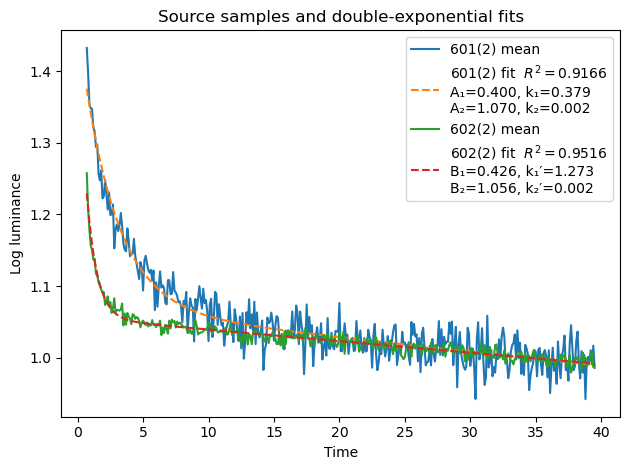

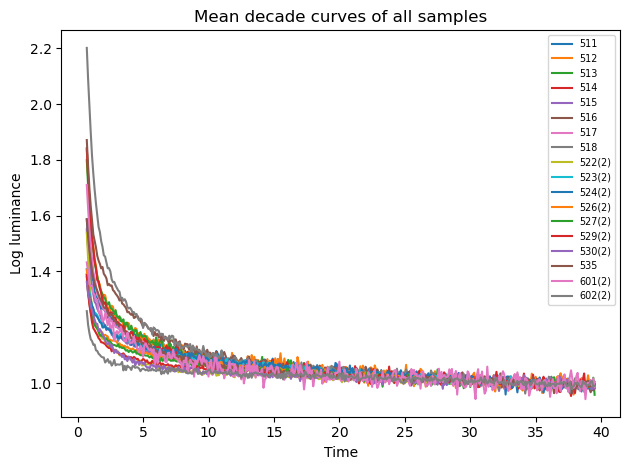

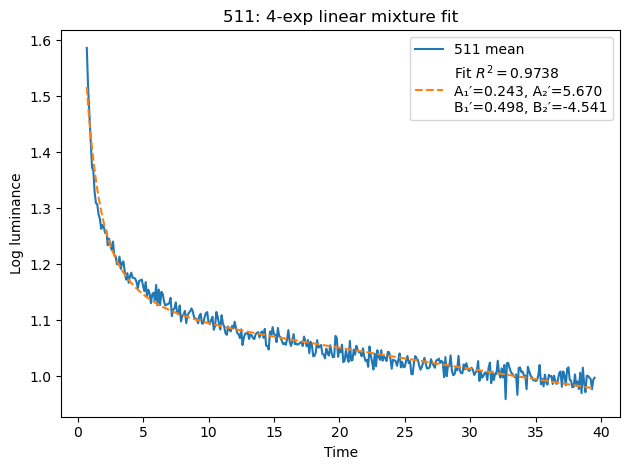

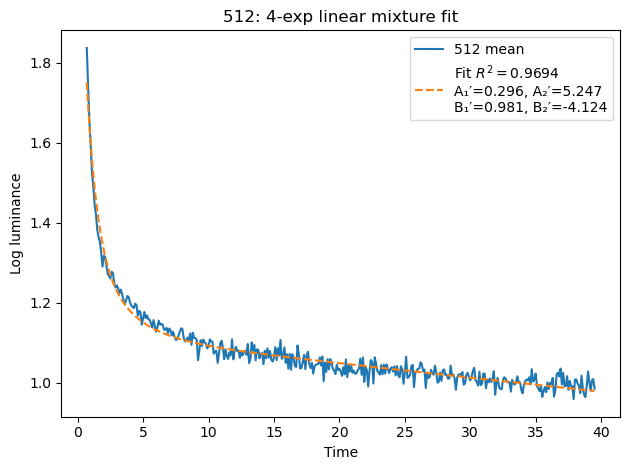

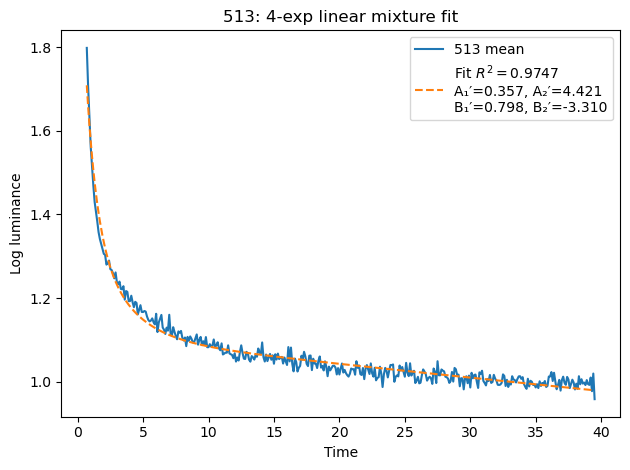

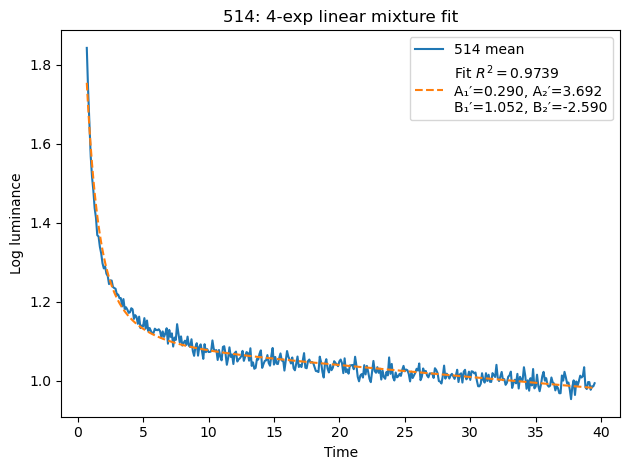

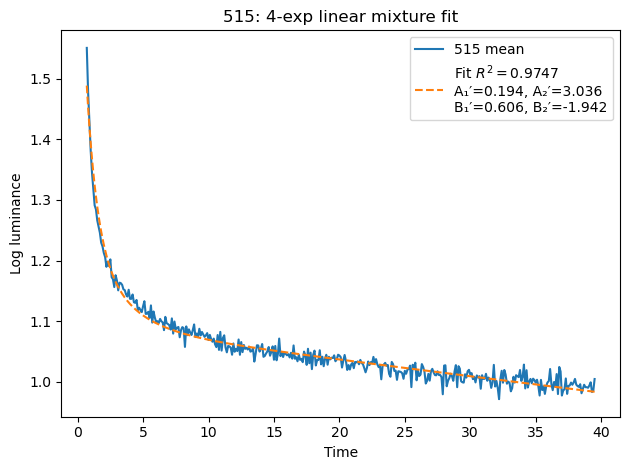

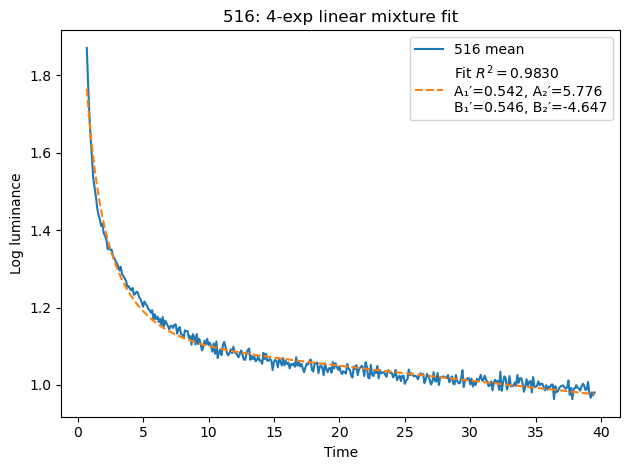

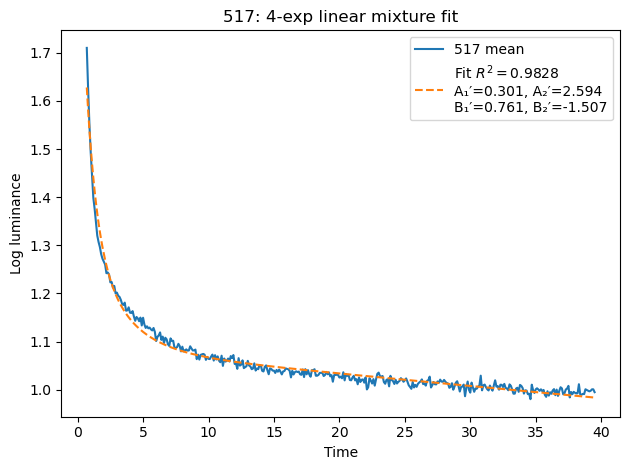

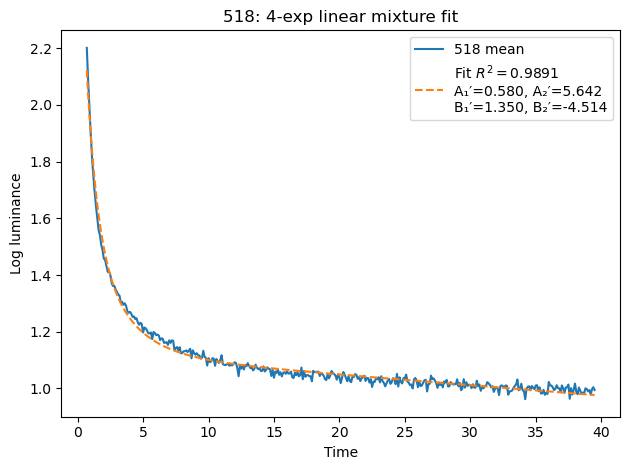

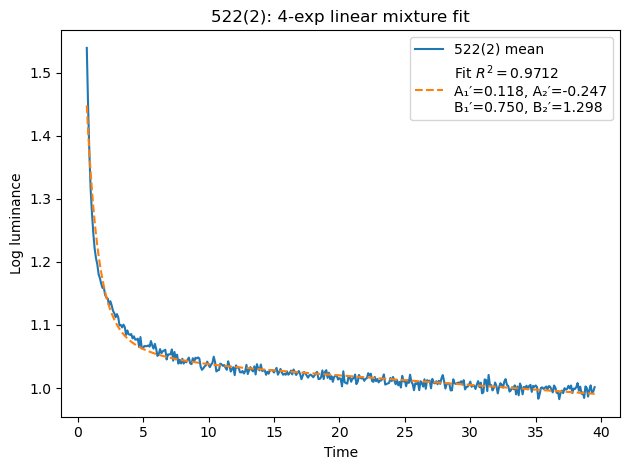

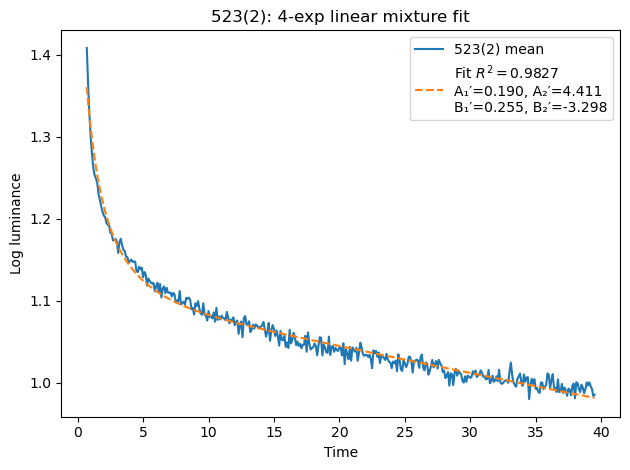

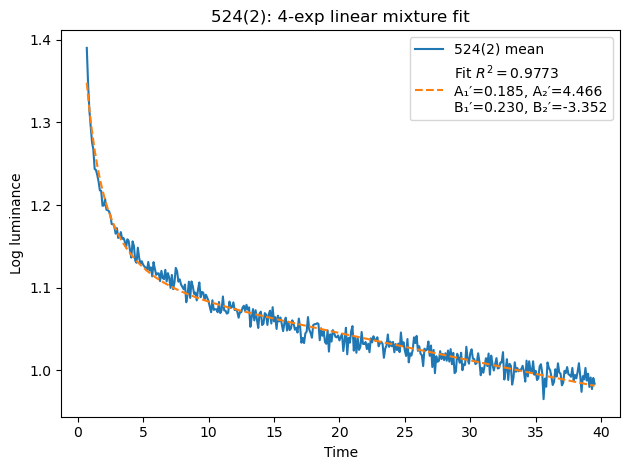

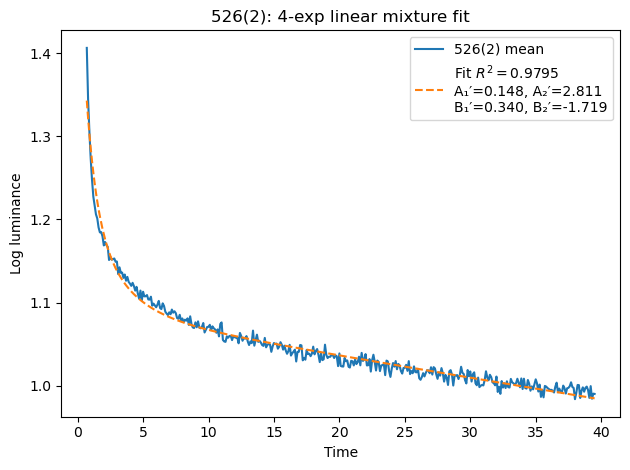

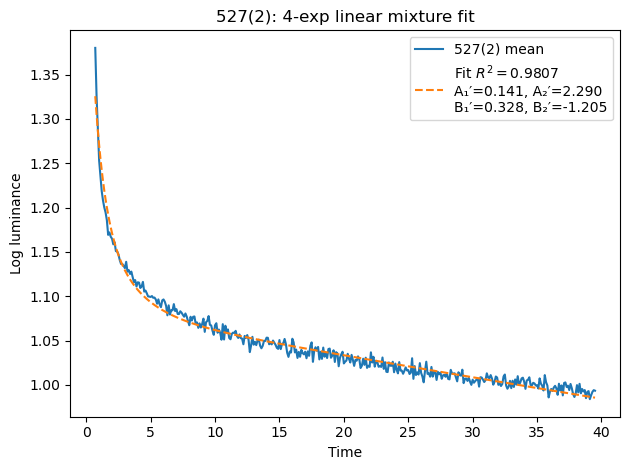

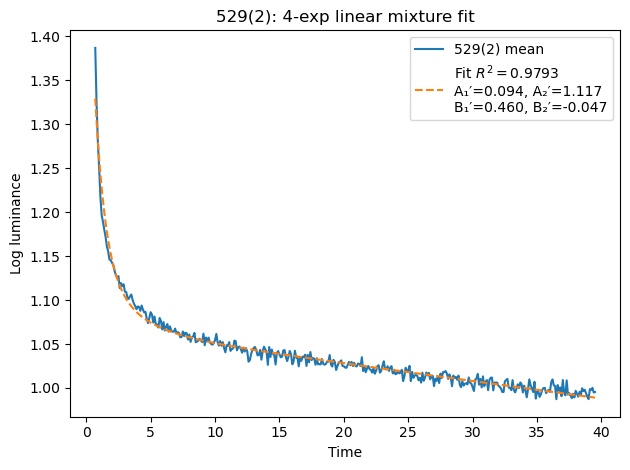

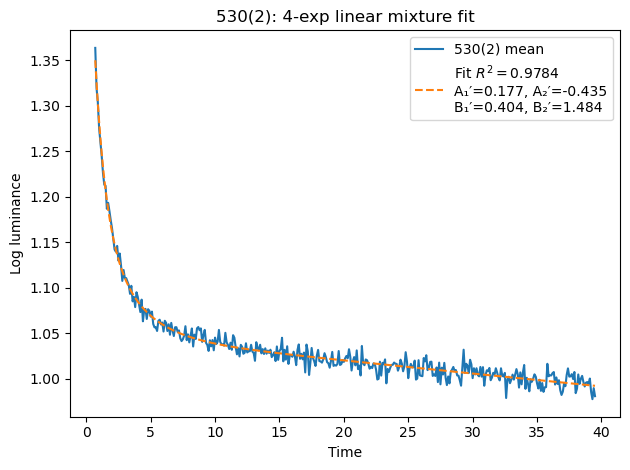

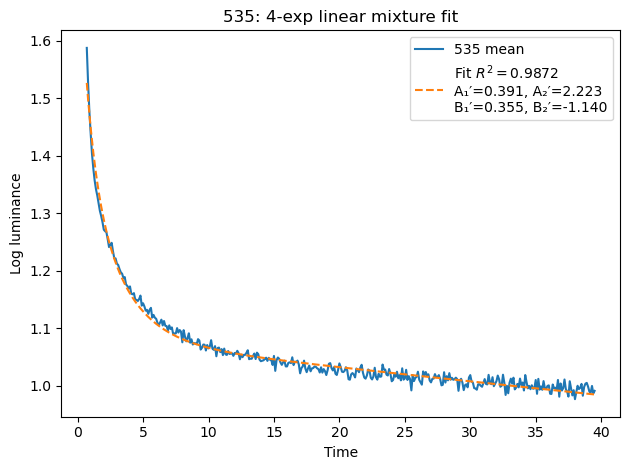

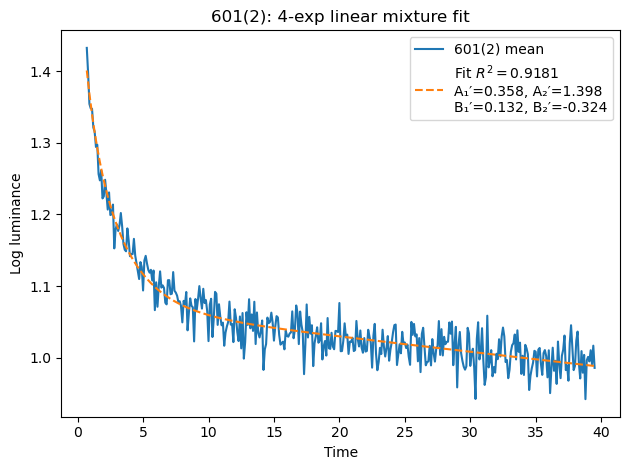

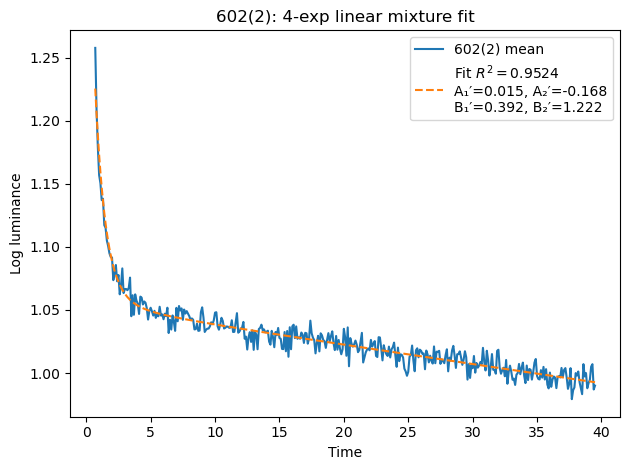

Linear‑mixture coefficients (A1', A2', B1', B2', R²) for every sample:
511    :    0.2426    5.6703    0.4981   -4.5413    R²=0.9738
512    :    0.2965    5.2473    0.9812   -4.1238    R²=0.9694
513    :    0.3571    4.4210    0.7985   -3.3105    R²=0.9747
514    :    0.2904    3.6918    1.0518   -2.5898    R²=0.9739
515    :    0.1936    3.0357    0.6057   -1.9417    R²=0.9747
516    :    0.5421    5.7758    0.5457   -4.6471    R²=0.9830
517    :    0.3006    2.5941    0.7609   -1.5067    R²=0.9828
518    :    0.5803    5.6415    1.3496   -4.5142    R²=0.9891
522(2) :    0.1179   -0.2471    0.7505    1.2979    R²=0.9712
523(2) :    0.1902    4.4113    0.2552   -3.2985    R²=0.9827
524(2) :    0.1853    4.4655    0.2300   -3.3516    R²=0.9773
526(2) :    0.1480    2.8110    0.3403   -1.7192    R²=0.9795
527(2) :    0.1414    2.2900    0.3280   -1.2055    R²=0.9807
529(2) :    0.0945    1.1169    0.4598   -0.0469    R²=0.9793
530(2) :    0.1769   -0.4347    0.4041    1.4840    R²=0.9784

In [3]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -------------------- Helper utilities --------------------
def load_data(path="output/processed_new_data_log.pkl"):
    """Load the pickled dictionary that contains all sample dataframes."""
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Pickle file not found at '{path}'. Please make sure the path is correct."
        )
    with open(path, "rb") as f:
        return pickle.load(f)


def mean_curve(df, key):
    """
    Return time vector and the mean of all slice columns for a given dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe corresponding to one sample.
    key : str
        The sample key, e.g. '601(2)' or '511'.  The part before a '(' (if any)
        is used to match slice‑column names, e.g. 'Sample_601'.
    """
    prefix = f"Sample_{key.split('(')[0]}"
    slice_cols = [c for c in df.columns if c.startswith(prefix)]
    t = df["Time"].values.astype(float)
    y = df[slice_cols].mean(axis=1).values.astype(float)
    return t, y


def double_exp(t, A1, k1, A2, k2):
    """Two‑term exponential decay."""
    return A1 * np.exp(-k1 * t) + A2 * np.exp(-k2 * t)


def r2_score(y_true, y_pred):
    sst = np.sum((y_true - np.mean(y_true)) ** 2)
    sse = np.sum((y_true - y_pred) ** 2)
    return 1.0 - sse / sst


# -------------------- STEP 1: fit the two “source” samples --------------------
data_dict = load_data()

# Fit sample 601(2)
t_601, y_601 = mean_curve(data_dict["601(2)"], "601(2)")
p0_601 = [1.0, 0.05, 0.5, 0.005]  # rough starting guesses
A1, k1, A2, k2 = curve_fit(double_exp, t_601, y_601, p0=p0_601, maxfev=10000)[0]
fit_601 = double_exp(t_601, A1, k1, A2, k2)
r2_601 = r2_score(y_601, fit_601)

# Fit sample 602(2)
t_602, y_602 = mean_curve(data_dict["602(2)"], "602(2)")
p0_602 = [A1, k1, A2, k2]  # use previous fit as a reasonable initial guess
B1, k1b, B2, k2b = curve_fit(double_exp, t_602, y_602, p0=p0_602, maxfev=10000)[0]
fit_602 = double_exp(t_602, B1, k1b, B2, k2b)
r2_602 = r2_score(y_602, fit_602)

# Plot the two means and their double‑exponential fits
plt.figure()
plt.plot(t_601, y_601, label="601(2) mean")
plt.plot(
    t_601,
    fit_601,
    "--",
    label=(
        f"601(2) fit  $R^2={r2_601:.4f}$\n"
        f"A₁={A1:.3f}, k₁={k1:.3f}\nA₂={A2:.3f}, k₂={k2:.3f}"
    ),
)
plt.plot(t_602, y_602, label="602(2) mean")
plt.plot(
    t_602,
    fit_602,
    "--",
    label=(
        f"602(2) fit  $R^2={r2_602:.4f}$\n"
        f"B₁={B1:.3f}, k₁′={k1b:.3f}\nB₂={B2:.3f}, k₂′={k2b:.3f}"
    ),
)
plt.xlabel("Time")
plt.ylabel("Log luminance")
plt.title("Source samples and double‑exponential fits")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------- STEP 2: model every sample as a linear mix of the 4 exponentials --------------------
# Basis functions (no amplitudes) derived from the two fitted source samples
def basis_matrix(t, k1=k1, k2=k2, k1b=k1b, k2b=k2b):
    """Return a (len(t)×4) matrix of the four basis exponentials at times t."""
    return np.column_stack(
        [
            np.exp(-k1 * t),   # basis f₁ from 601(2)
            np.exp(-k2 * t),   # basis f₂ from 601(2)
            np.exp(-k1b * t),  # basis g₁ from 602(2)
            np.exp(-k2b * t),  # basis g₂ from 602(2)
        ]
    )


# (a) A single chart showing the mean curve of every sample
plt.figure()
for sample_key in data_dict:
    t, y = mean_curve(data_dict[sample_key], sample_key)
    plt.plot(t, y, label=sample_key)
plt.xlabel("Time")
plt.ylabel("Log luminance")
plt.title("Mean decade curves of all samples")
plt.legend(fontsize="x-small")
plt.tight_layout()
plt.show()

# (b) Fit each sample to the four‑function model and chart mean vs. fit
coeffs_summary = {}
for sample_key in data_dict:
    t, y = mean_curve(data_dict[sample_key], sample_key)
    X = basis_matrix(t, k1, k2, k1b, k2b)
    # Linear least‑squares solve for A1', A2', B1', B2'
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ coef
    r2_val = r2_score(y, y_hat)
    coeffs_summary[sample_key] = (*coef, r2_val)

    # Plot mean curve and the 4‑exp fit
    plt.figure()
    plt.plot(t, y, label=f"{sample_key} mean")
    plt.plot(
        t,
        y_hat,
        "--",
        label=(
            f"Fit $R^2={r2_val:.4f}$\n"
            f"A₁′={coef[0]:.3f}, A₂′={coef[1]:.3f}\n"
            f"B₁′={coef[2]:.3f}, B₂′={coef[3]:.3f}"
        ),
    )
    plt.xlabel("Time")
    plt.ylabel("Log luminance")
    plt.title(f"{sample_key}: 4‑exp linear mixture fit")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Optional: print the coefficient table for quick reference
print("Linear‑mixture coefficients (A1', A2', B1', B2', R²) for every sample:")
for k, (c1, c2, c3, c4, r2v) in coeffs_summary.items():
    print(f"{k:7s}:  {c1:8.4f}  {c2:8.4f}  {c3:8.4f}  {c4:8.4f}    R²={r2v:.4f}")


# print A1, A2, B1, B2 AND k1, k2, k1b, k2b
print(f"A1: {A1:.3f}, A2: {A2:.3f}, B1: {B1:.3f}, B2: {B2:.3f}")
print(f"k1: {k1:.3f}, k2: {k2:.3f}, k1b: {k1b:.3f}, k2b: {k2b:.3f}")

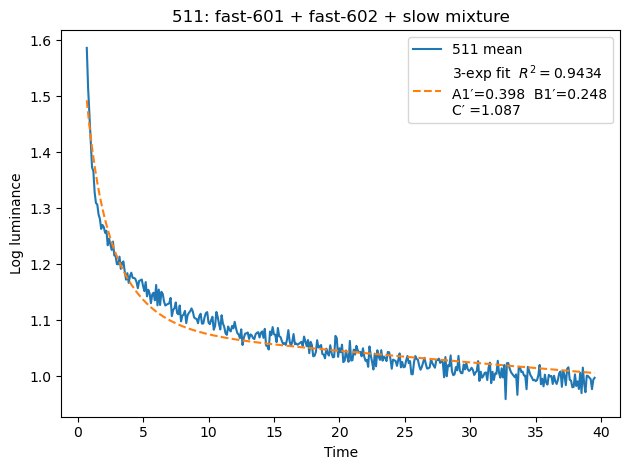

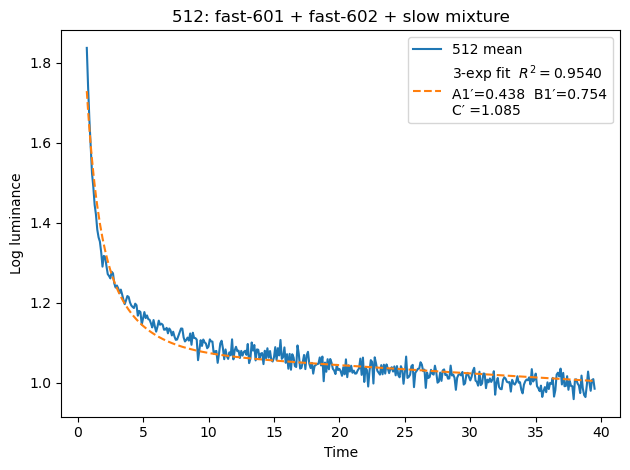

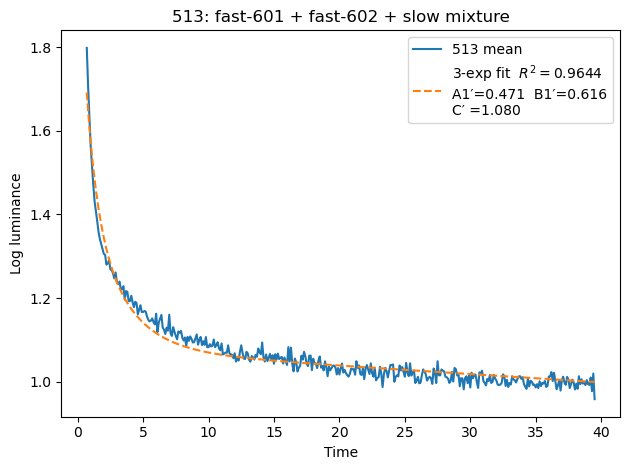

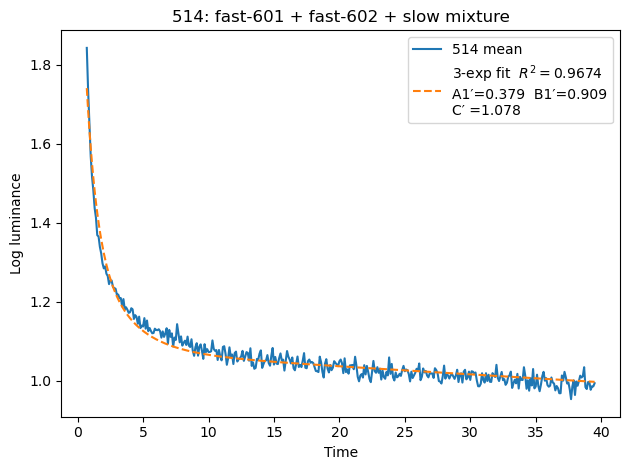

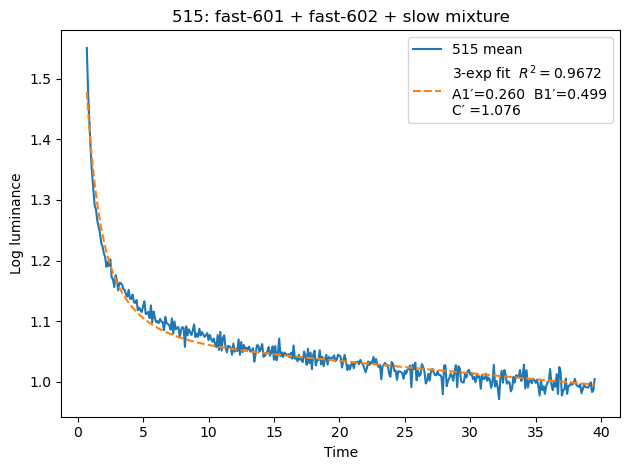

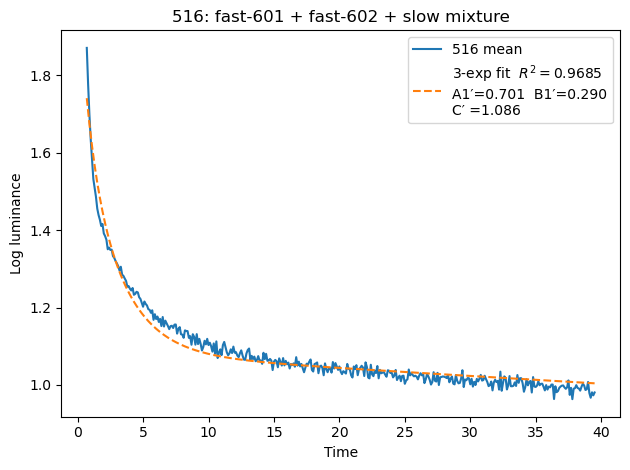

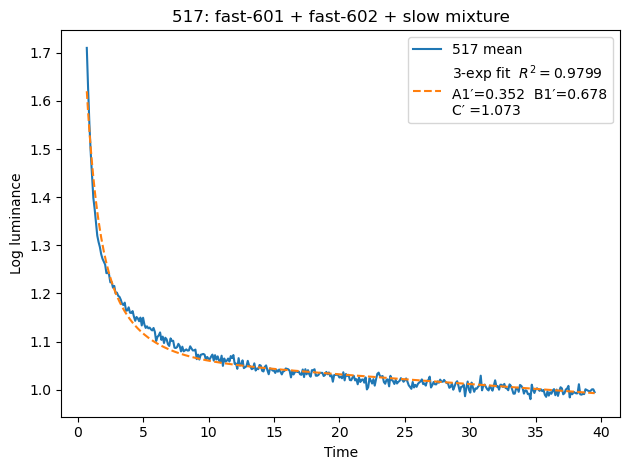

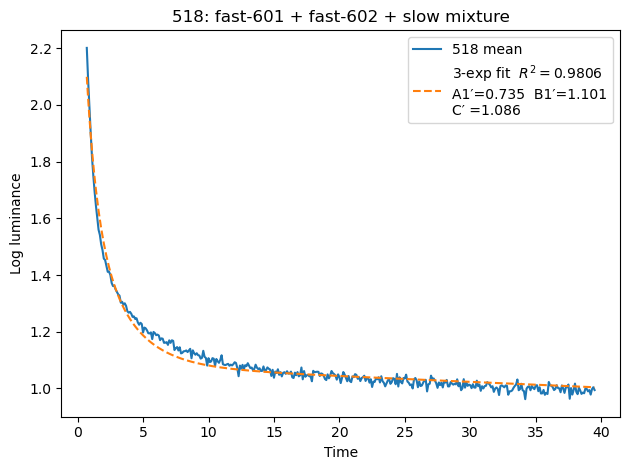

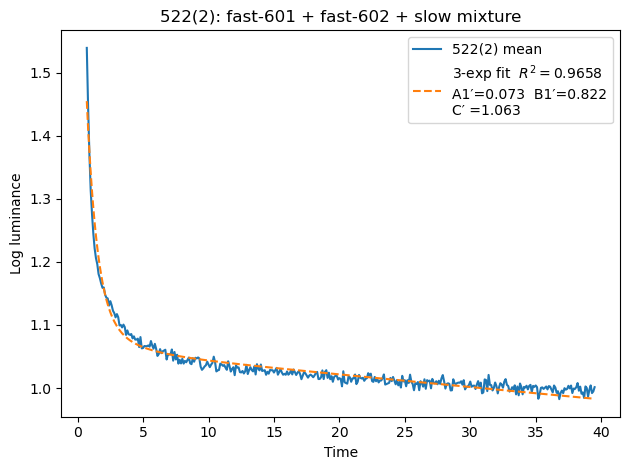

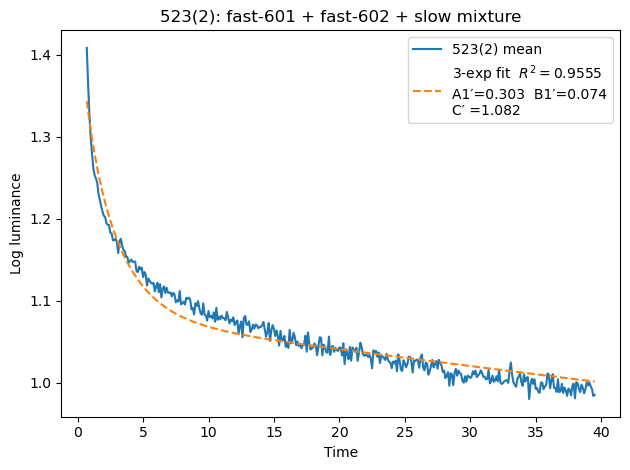

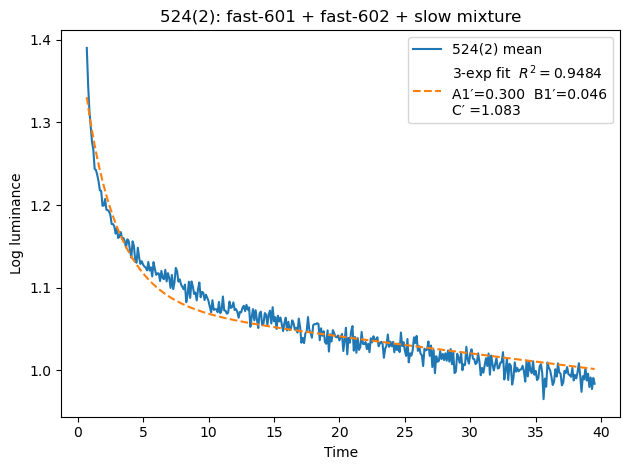

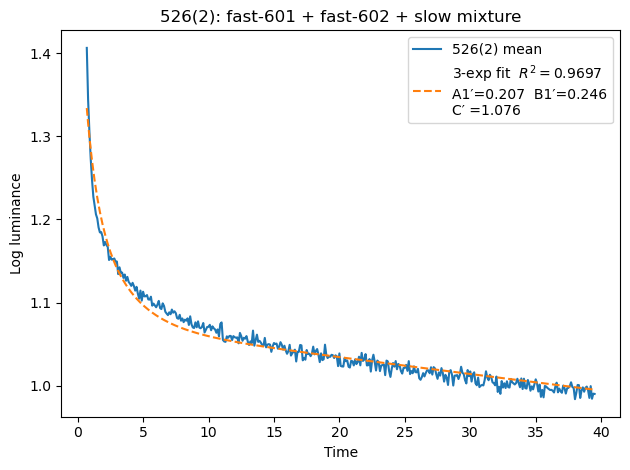

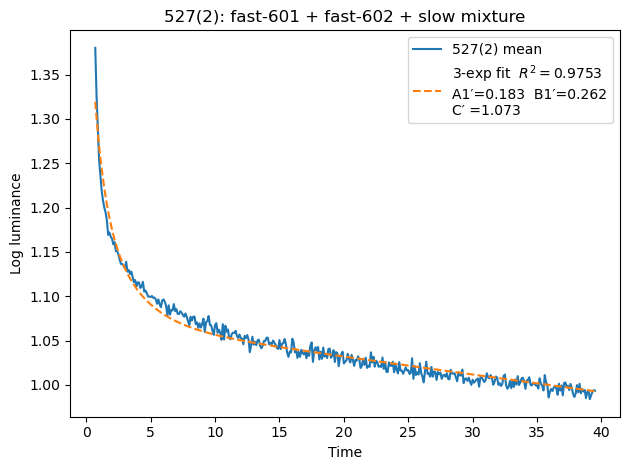

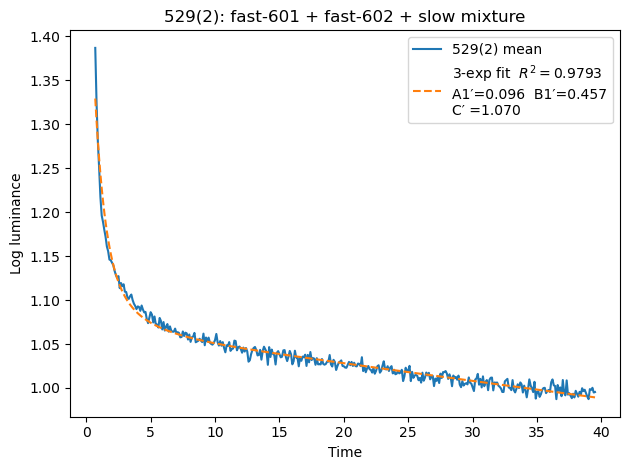

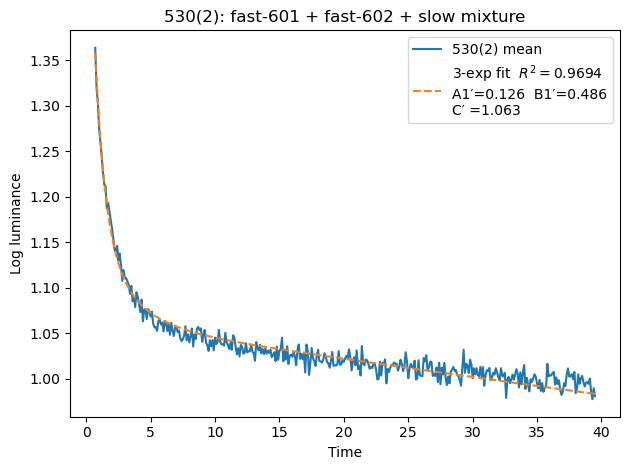

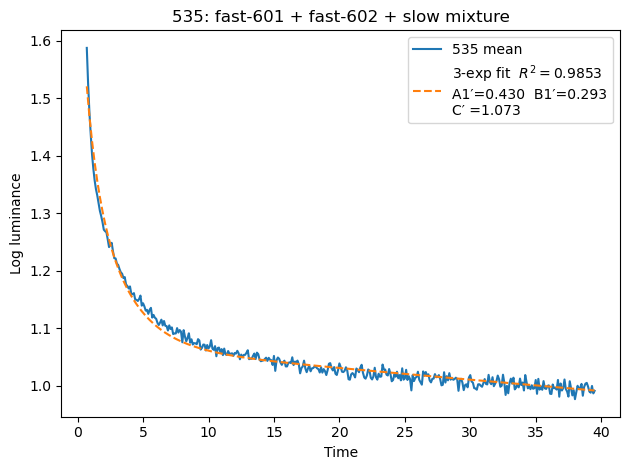

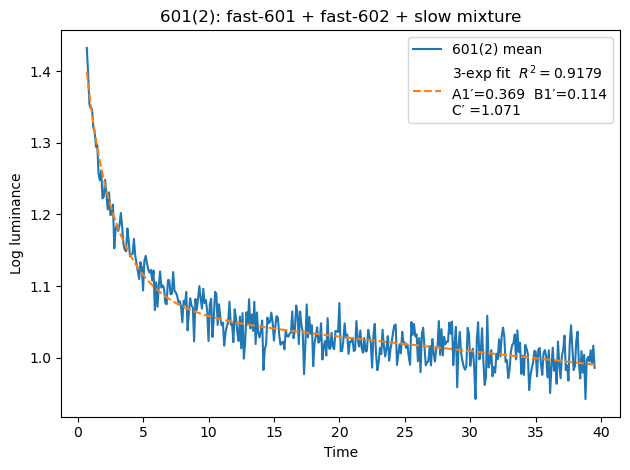

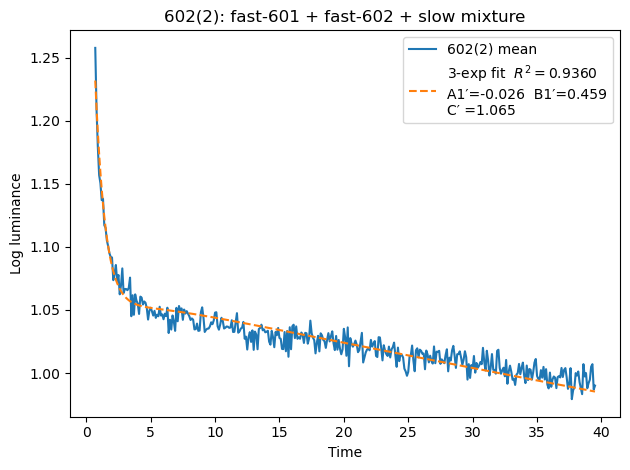

Sample   A1′(fast‑601)  B1′(fast‑602)   C′(slow)    R²
511             0.3983         0.2484      1.0870   0.9434
512             0.4378         0.7544      1.0854   0.9540
513             0.4706         0.6164      1.0800   0.9644
514             0.3792         0.9094      1.0781   0.9674
515             0.2602         0.4990      1.0760   0.9672
516             0.7014         0.2901      1.0858   0.9685
517             0.3522         0.6780      1.0735   0.9799
518             0.7350         1.1014      1.0856   0.9806
522(2)          0.0734         0.8219      1.0628   0.9658
523(2)          0.3033         0.0738      1.0824   0.9555
524(2)          0.3001         0.0457      1.0830   0.9484
526(2)          0.2069         0.2458      1.0760   0.9697
527(2)          0.1827         0.2617      1.0734   0.9753
529(2)          0.0961         0.4573      1.0696   0.9793
530(2)          0.1260         0.4857      1.0631   0.9694
535             0.4296         0.2926      1.0726   0.9853
6

In [4]:
# -----------------------------------------------------------
#  STEP 2‑alt: 3‑exponential mixture (fast‑601, fast‑602, slow)
#              amplitudes = A1′, B1′, C′ ; rates fixed = k1,k1b,k2
# -----------------------------------------------------------

# --- 3‑column basis:  exp(‑k1 t), exp(‑k1b t), exp(‑k2 t)
def basis_matrix3(t, k1=k1, k1b=k1b, k2=k2):
    return np.column_stack([np.exp(-k1 * t), np.exp(-k1b * t), np.exp(-k2 * t)])

coef_table = {}          # {sample: (A1′, B1′, C′, R²)}

for sample_key, df in data_dict.items():
    t, y = mean_curve(df, sample_key)

    # linear LSQ for A1′, B1′, C′
    X3          = basis_matrix3(t)
    coeffs, *_  = np.linalg.lstsq(X3, y, rcond=None)
    y_fit       = X3 @ coeffs
    r2_val      = r2_score(y, y_fit)
    coef_table[sample_key] = (*coeffs, r2_val)

    # ---- plotting ----
    plt.figure()
    plt.plot(t, y,  label=f"{sample_key} mean")
    plt.plot(t, y_fit, "--",
             label=(f"3‑exp fit  $R^2={r2_val:.4f}$\n"
                    f"A1′={coeffs[0]:.3f}  "
                    f"B1′={coeffs[1]:.3f}\n"
                    f"C′ ={coeffs[2]:.3f}"))
    plt.xlabel("Time")
    plt.ylabel("Log luminance")
    plt.title(f"{sample_key}: fast‑601 + fast‑602 + slow mixture")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ---- concise coefficient summary ----
print("Sample   A1′(fast‑601)  B1′(fast‑602)   C′(slow)    R²")
for k, (a1p, b1p, cp, r2v) in coef_table.items():
    print(f"{k:7s}  {a1p:13.4f}{b1p:15.4f}{cp:12.4f}   {r2v:.4f}")


In [6]:
import pandas as pd

coef_table = {
    "511":    (0.3983, 0.2484, 1.0870, 0.9434),
    "512":    (0.4378, 0.7544, 1.0854, 0.9540),
    "513":    (0.4706, 0.6164, 1.0800, 0.9644),
    "514":    (0.3792, 0.9094, 1.0781, 0.9674),
    "515":    (0.2602, 0.4990, 1.0760, 0.9672),
    "516":    (0.7014, 0.2901, 1.0858, 0.9685),
    "517":    (0.3522, 0.6780, 1.0735, 0.9799),
    "518":    (0.7350, 1.1014, 1.0856, 0.9806),
    "522(2)": (0.0734, 0.8219, 1.0628, 0.9658),
    "523(2)": (0.3033, 0.0738, 1.0824, 0.9555),
    "524(2)": (0.3001, 0.0457, 1.0830, 0.9484),
    "526(2)": (0.2069, 0.2458, 1.0760, 0.9697),
    "527(2)": (0.1827, 0.2617, 1.0734, 0.9753),
    "529(2)": (0.0961, 0.4573, 1.0696, 0.9793),
    "530(2)": (0.1260, 0.4857, 1.0631, 0.9694),
    "535":    (0.4296, 0.2926, 1.0726, 0.9853),
    "601(2)": (0.3695, 0.1142, 1.0707, 0.9179),  # source sample, to exclude
    "602(2)": (-0.0264, 0.4589, 1.0653, 0.9360), # source sample, to exclude
}


records = []
for smp, (a1p, b1p, cp, r2) in coef_table.items():
    if smp in ["601(2)", "602(2)"]:   # exclude sources
        continue
    total = a1p + b1p
    frac601 = a1p / total if total else float("nan")
    frac602 = b1p / total if total else float("nan")
    records.append([smp, a1p, b1p, cp, frac601, frac602, r2])

df = pd.DataFrame(
    records,
    columns=["Sample", "A1′ (fast‑601)", "B1′ (fast‑602)",
             "C′ (slow)", "Mix 601 (frac)", "Mix 602 (frac)", "R²"]
).set_index("Sample")

# display or print
from IPython.display import display
display(df.round(4))          # or: print(df.round(4).to_string())


,A1′ (fast‑601),B1′ (fast‑602),C′ (slow),Mix 601 (frac),Mix 602 (frac),R²
Sample,,,,,,
511,0.3983,0.2484,1.0870,0.6159,0.3841,0.9434
512,0.4378,0.7544,1.0854,0.3672,0.6328,0.9540
513,0.4706,0.6164,1.0800,0.4329,0.5671,0.9644
514,0.3792,0.9094,1.0781,0.2943,0.7057,0.9674
515,0.2602,0.4990,1.0760,0.3427,0.6573,0.9672
516,0.7014,0.2901,1.0858,0.7074,0.2926,0.9685
517,0.3522,0.6780,1.0735,0.3419,0.6581,0.9799
518,0.7350,1.1014,1.0856,0.4002,0.5998,0.9806
522(2),0.0734,0.8219,1.0628,0.0820,0.9180,0.9658


In [10]:
import os
import pickle
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import plotly.express as px

# ------------------------------------------------------------
# Helper utilities (same as in your script)
# ------------------------------------------------------------
def load_data(path="output/processed_new_data_log.pkl"):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Pickle file not found at '{path}'. Please make sure the path is correct or upload it."
        )
    with open(path, "rb") as f:
        return pickle.load(f)

def mean_curve(df, key):
    prefix = f"Sample_{key.split('(')[0]}"
    slice_cols = [c for c in df.columns if c.startswith(prefix)]
    t = df["Time"].values.astype(float)
    y = df[slice_cols].mean(axis=1).values.astype(float)
    return t, y

def double_exp(t, A1, k1, A2, k2):
    return A1 * np.exp(-k1 * t) + A2 * np.exp(-k2 * t)

def basis_matrix3(t, k1, k1b, k2):
    return np.column_stack([np.exp(-k1 * t), np.exp(-k1b * t), np.exp(-k2 * t)])

# ------------------------------------------------------------
# 1. Load data & fit source samples to get the three decay rates
# ------------------------------------------------------------
data_dict = load_data()

# --- Fit 601(2) ---
t601, y601 = mean_curve(data_dict["601(2)"], "601(2)")
p0_601 = [1.0, 0.05, 0.5, 0.005]           # rough starting guesses
A1, k1, A2, k2 = curve_fit(double_exp, t601, y601, p0=p0_601, maxfev=10000)[0]

# --- Fit 602(2) ---
t602, y602 = mean_curve(data_dict["602(2)"], "602(2)")
p0_602 = [A1, k1, A2, k2]
B1, k1b, B2, k2b = curve_fit(double_exp, t602, y602, p0=p0_602, maxfev=10000)[0]

# Use k1 (fast‑601), k1b (fast‑602), and k2 (shared slow) as fixed rates
print(f"Using decay rates k1={k1:.4f}, k1b={k1b:.4f}, k2={k2:.4f}")

# ------------------------------------------------------------
# 2. Fit every sample as A1′*e^(‑k1t) + B1′*e^(‑k1b t) + C′*e^(‑k2 t)
# ------------------------------------------------------------
rows = []
for sample_key, df in data_dict.items():
    t, y = mean_curve(df, sample_key)
    X3 = basis_matrix3(t, k1, k1b, k2)
    coeffs, *_ = np.linalg.lstsq(X3, y, rcond=None)
    rows.append(dict(Sample=sample_key, A1p=coeffs[0], B1p=coeffs[1], Cp=coeffs[2]))

coef_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# 3. Interactive 3‑D scatter plot
# ------------------------------------------------------------
fig = px.scatter_3d(
    coef_df,
    x="A1p",
    y="B1p",
    z="Cp",
    text="Sample",
    title="Three‑component amplitudes for each sample\n(fast‑601, fast‑602, shared‑slow)",
)
fig.update_traces(marker=dict(size=5))
fig.update_layout(scene=dict(
    xaxis_title="A1′  (fast‑601 amplitude)",
    yaxis_title="B1′  (fast‑602 amplitude)",
    zaxis_title="C′   (slow amplitude)"
))
fig.show()




Using decay rates k1=0.3792, k1b=1.2733, k2=0.0020
